In [1]:
import os
import sys

sys.stderr = open(os.devnull, "w")

import warnings
import multiprocessing as mp
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import psycopg2
import pytz
import pmdarima as pm
from itertools import product
from functools import partial
from datetime import timedelta
from dateutil.relativedelta import relativedelta
from statsmodels.tsa.statespace.sarimax import SARIMAX
from scipy.stats import norm
from sklearn.utils import resample
from sklearn.metrics import mean_absolute_error, root_mean_squared_error
from fit_sarimax import *

warnings.filterwarnings('ignore', category=FutureWarning)

np.random.seed(42)

In [2]:
sales = pd.read_csv('pedidos-1743765883268.csv', sep=';', encoding='latin1')

In [3]:
df = sales[['account_id', 'sales_channel_id']].value_counts()
df = pd.DataFrame(df).reset_index()

In [4]:
pd.to_datetime('2025-03-31 00:00:00')

Timestamp('2025-03-31 00:00:00')

In [5]:
SAO_PAULO_TZ = pytz.timezone('America/Sao_Paulo')
LOOKBACK = 1
END_DATE = pd.to_datetime(pd.to_datetime(sales['created_date'].max()).strftime("%Y-%m-%d %H:00:00"))
# START_DATE = END_DATE - timedelta(hours=END_DATE.hour)
START_DATE = END_DATE - timedelta(hours=23)
TEST_SIZE = int((END_DATE - START_DATE).seconds / 60**2 + 1)

In [6]:
# OOT_DATE = START_DATE + timedelta(hours=23)

In [7]:
# OOT_PERIODS = int((OOT_DATE - END_DATE).seconds / 60**2 + 1)

In [8]:
# oot_dates = pd.DatetimeIndex([END_DATE+timedelta(hours=h) for h in range(1, OOT_PERIODS)], freq='h')
# df_oot = pd.DataFrame(index=oot_dates)

In [9]:
df.drop('count', axis=1, inplace=True)
for account_id in df['account_id'].unique():
    df = pd.concat([df, pd.DataFrame({'account_id': [account_id], 'sales_channel_id': ['ALL']})], ignore_index=True)

In [10]:
df[df['account_id'] == 'b8c6ac4b-2999-40f4-ad33-17649fb2f0aa']

,account_id,sales_channel_id
37,b8c6ac4b-2999-40f4-ad33-17649fb2f0aa,1
70,b8c6ac4b-2999-40f4-ad33-17649fb2f0aa,17
89,b8c6ac4b-2999-40f4-ad33-17649fb2f0aa,4
119,b8c6ac4b-2999-40f4-ad33-17649fb2f0aa,2
124,b8c6ac4b-2999-40f4-ad33-17649fb2f0aa,13
125,b8c6ac4b-2999-40f4-ad33-17649fb2f0aa,14
127,b8c6ac4b-2999-40f4-ad33-17649fb2f0aa,6
134,b8c6ac4b-2999-40f4-ad33-17649fb2f0aa,5
144,b8c6ac4b-2999-40f4-ad33-17649fb2f0aa,19
162,b8c6ac4b-2999-40f4-ad33-17649fb2f0aa,15


In [11]:
account_ids = ['f9129295-bb08-4330-b60c-9f0beadda521', '05d9cc3a-decc-4fa2-b4e8-b44eef40e3b6', '9d39683a-47b3-4a18-942d-f1d741a47e8c']

df_filtered = df[df['account_id'].isin(account_ids)]

In [12]:
df_filtered

,account_id,sales_channel_id
1,9d39683a-47b3-4a18-942d-f1d741a47e8c,1
2,05d9cc3a-decc-4fa2-b4e8-b44eef40e3b6,3
5,05d9cc3a-decc-4fa2-b4e8-b44eef40e3b6,6
7,f9129295-bb08-4330-b60c-9f0beadda521,1
11,f9129295-bb08-4330-b60c-9f0beadda521,2
15,05d9cc3a-decc-4fa2-b4e8-b44eef40e3b6,5
29,f9129295-bb08-4330-b60c-9f0beadda521,10
48,f9129295-bb08-4330-b60c-9f0beadda521,38
51,f9129295-bb08-4330-b60c-9f0beadda521,16
55,f9129295-bb08-4330-b60c-9f0beadda521,18


In [13]:
dbname = 'railway'
username = 'sinatra'
pwd = '781B3XjpeuqE'
hostname = 'monorail.proxy.rlwy.net'
port = 25096

connection = psycopg2.connect(database=dbname, user=username, password=pwd, host=hostname, port=port)
cursor = connection.cursor()

In [ ]:
cursor.execute("select distinct account_id, channel from public.forecast where model like 'SARIMAX';")

In [15]:
res_forecast = cursor.fetchall()

In [16]:
res_forecast

[('05d9cc3a-decc-4fa2-b4e8-b44eef40e3b6', '1'),
 ('05d9cc3a-decc-4fa2-b4e8-b44eef40e3b6', '3'),
 ('05d9cc3a-decc-4fa2-b4e8-b44eef40e3b6', '5'),
 ('05d9cc3a-decc-4fa2-b4e8-b44eef40e3b6', '6'),
 ('9d39683a-47b3-4a18-942d-f1d741a47e8c', '1'),
 ('f9129295-bb08-4330-b60c-9f0beadda521', '1'),
 ('f9129295-bb08-4330-b60c-9f0beadda521', '10'),
 ('f9129295-bb08-4330-b60c-9f0beadda521', '16'),
 ('f9129295-bb08-4330-b60c-9f0beadda521', '18'),
 ('f9129295-bb08-4330-b60c-9f0beadda521', '2'),
 ('f9129295-bb08-4330-b60c-9f0beadda521', '38')]

account_id: f9129295-bb08-4330-b60c-9f0beadda521
sales_channel_id: ALL
price_total_agg
train RMSE: 184466.248
train MAE:  97311.284
test RMSE: 291156.727
test MAE:  255868.392


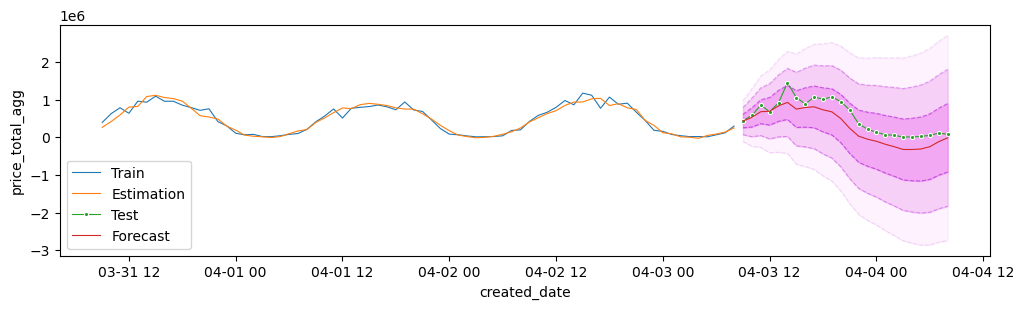

n_orders
train RMSE: 63.883
train MAE:  26.825
test RMSE: 102.323
test MAE:  88.297


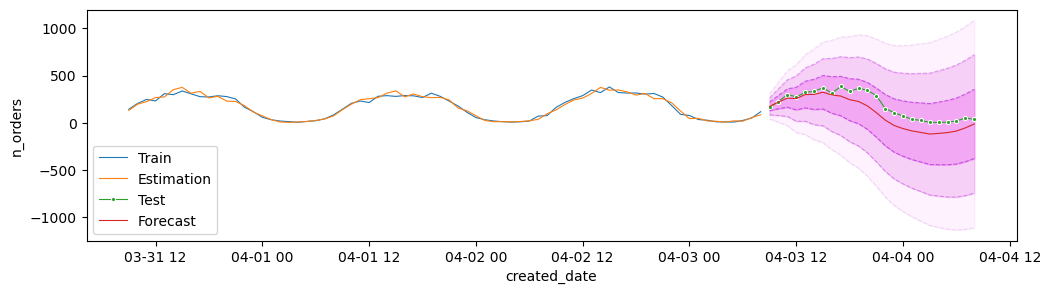

account_id: 05d9cc3a-decc-4fa2-b4e8-b44eef40e3b6
sales_channel_id: ALL
price_total_agg
train RMSE: 10951.710
train MAE:  7203.483
test RMSE: 8252.136
test MAE:  6475.099


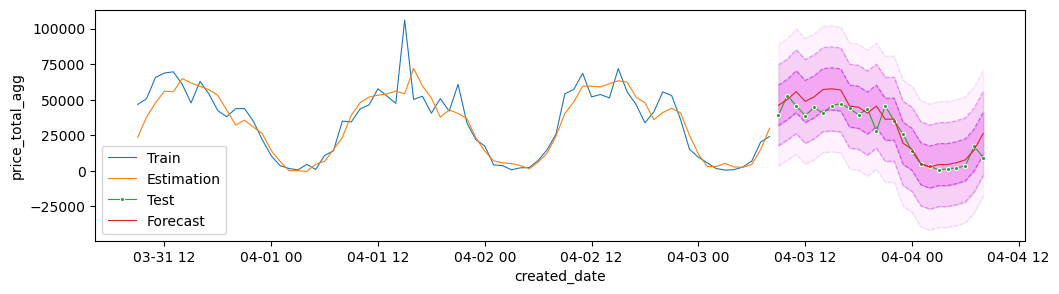

n_orders
train RMSE: 18.516
train MAE:  13.589
test RMSE: 21.290
test MAE:  13.586


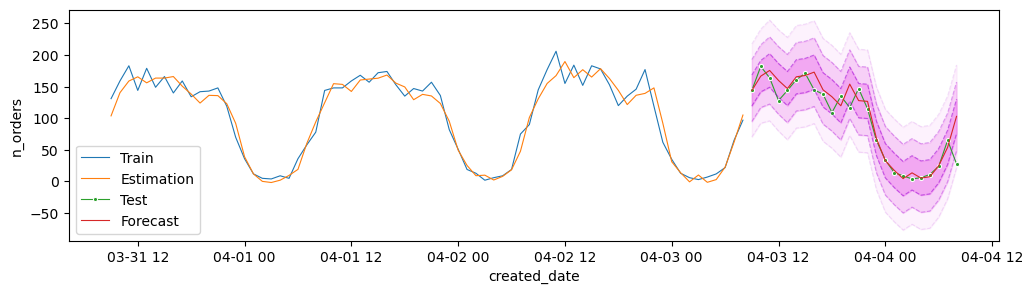

account_id: 9d39683a-47b3-4a18-942d-f1d741a47e8c
sales_channel_id: ALL
price_total_agg
train RMSE: 19279.586
train MAE:  13464.348
test RMSE: 17022.563
test MAE:  12771.388


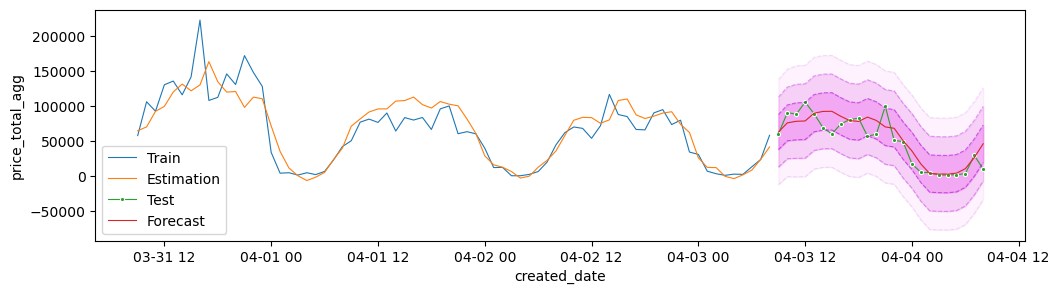

n_orders
train RMSE: 14.483
train MAE:  10.920
test RMSE: 18.213
test MAE:  12.878


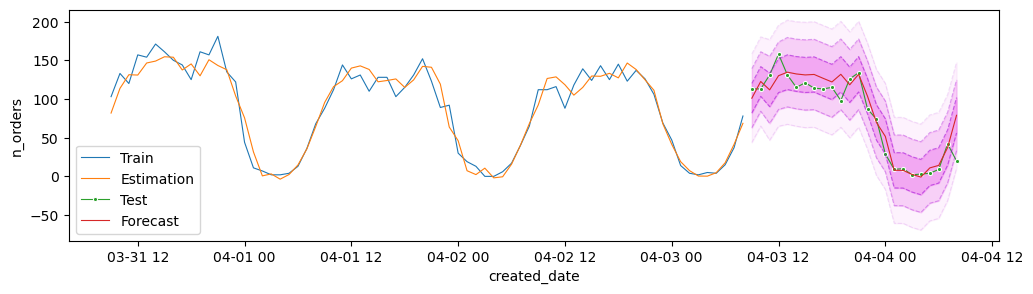

account_id: f9129295-bb08-4330-b60c-9f0beadda521
sales_channel_id: 36
price_total_agg
train RMSE: 244.615
train MAE:  9.269
test RMSE: 0.000
test MAE:  0.000


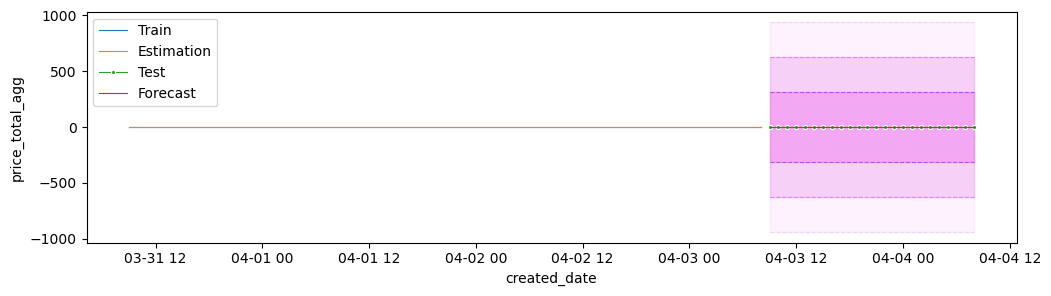

n_orders
train RMSE: 0.038
train MAE:  0.001
test RMSE: 0.000
test MAE:  0.000


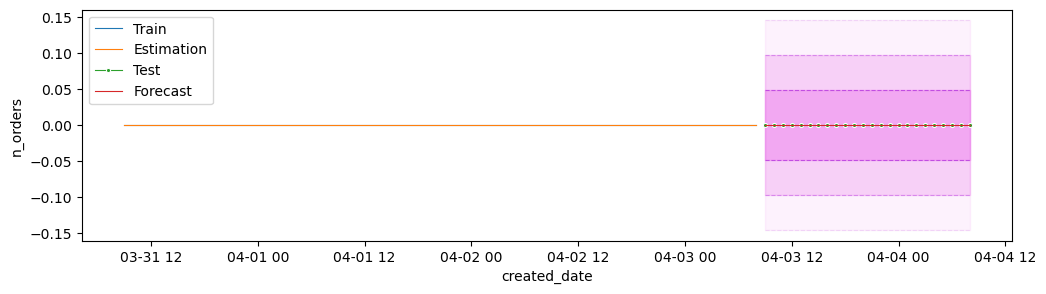

account_id: f9129295-bb08-4330-b60c-9f0beadda521
sales_channel_id: 8
price_total_agg
train RMSE: 0.000
train MAE:  0.000
test RMSE: 0.000
test MAE:  0.000


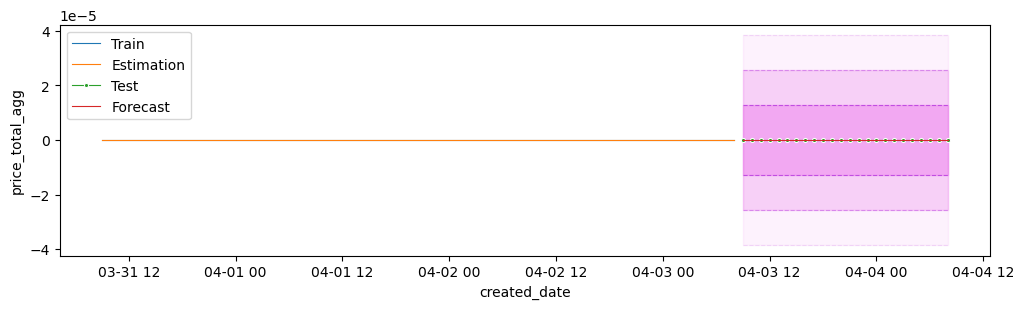

n_orders
train RMSE: 0.000
train MAE:  0.000
test RMSE: 0.000
test MAE:  0.000


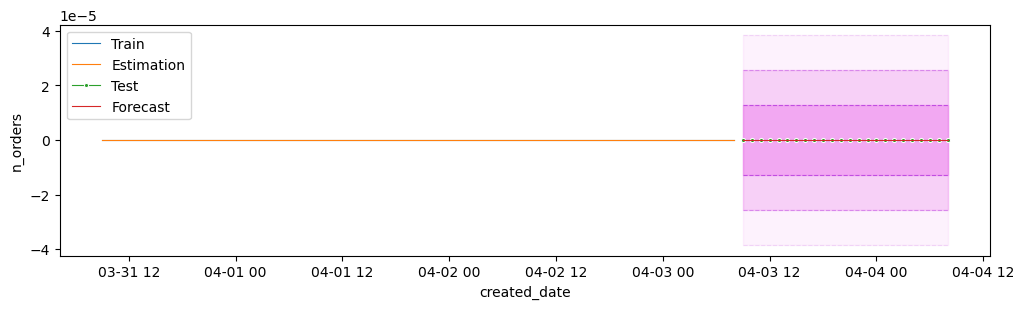

account_id: f9129295-bb08-4330-b60c-9f0beadda521
sales_channel_id: 5
price_total_agg
train RMSE: 0.000
train MAE:  0.000
test RMSE: 0.000
test MAE:  0.000


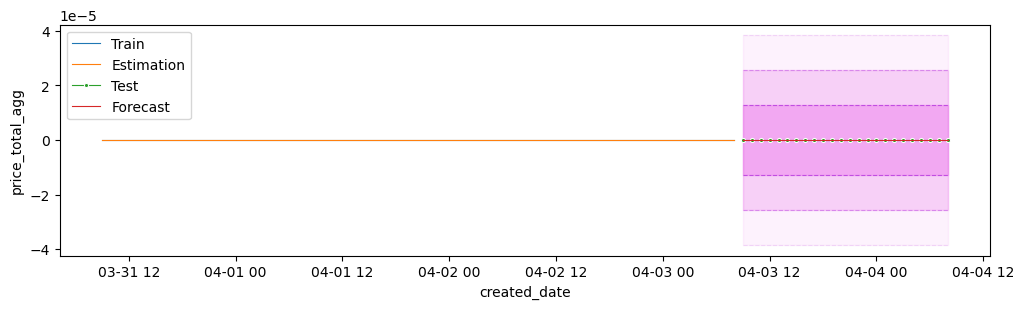

n_orders
train RMSE: 0.000
train MAE:  0.000
test RMSE: 0.000
test MAE:  0.000


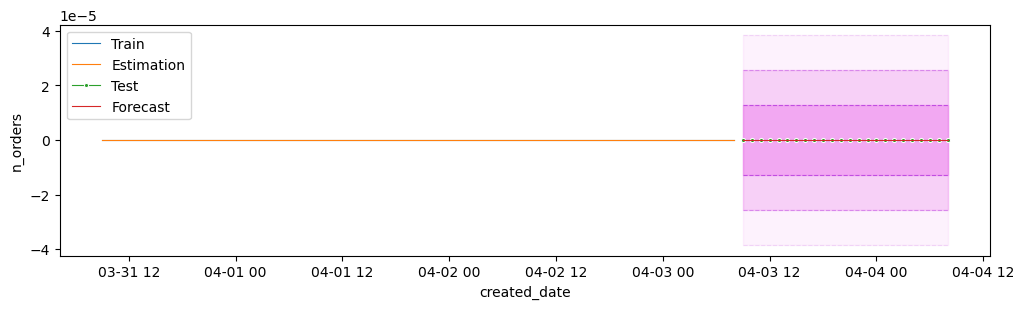

account_id: 05d9cc3a-decc-4fa2-b4e8-b44eef40e3b6
sales_channel_id: 4
price_total_agg
train RMSE: 0.000
train MAE:  0.000
test RMSE: 0.000
test MAE:  0.000


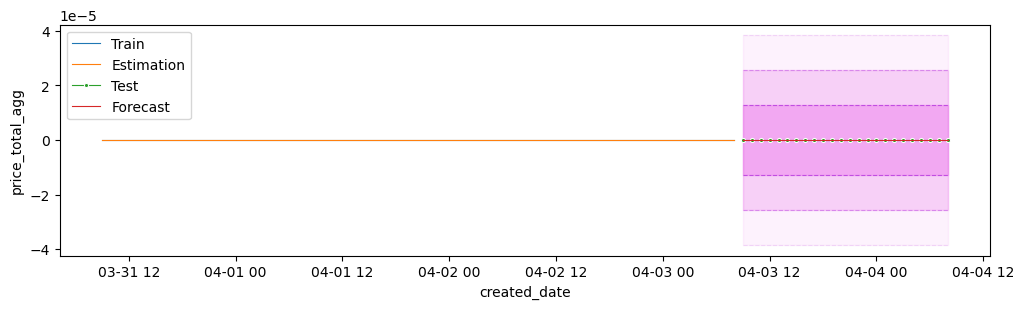

n_orders
train RMSE: 0.000
train MAE:  0.000
test RMSE: 0.000
test MAE:  0.000


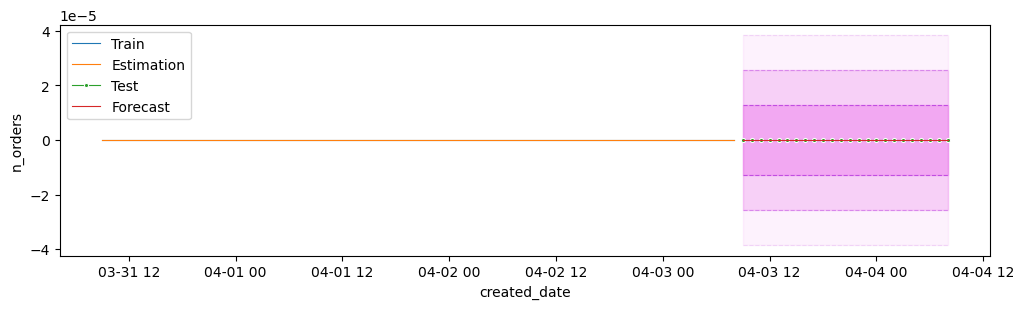

account_id: 9d39683a-47b3-4a18-942d-f1d741a47e8c
sales_channel_id: 2
price_total_agg
train RMSE: 0.000
train MAE:  0.000
test RMSE: 0.000
test MAE:  0.000


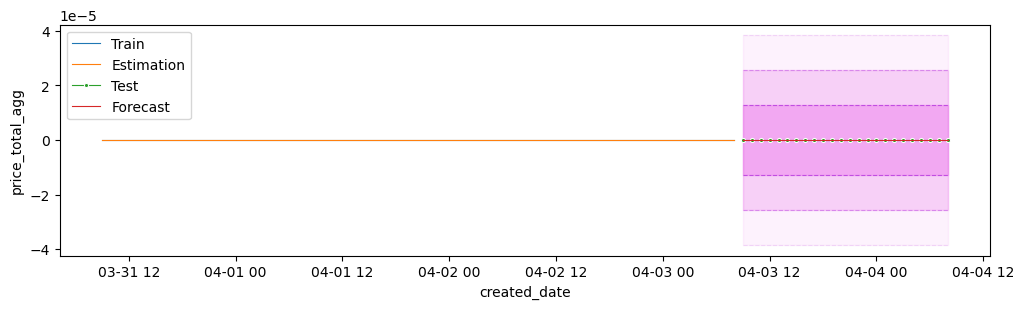

n_orders
train RMSE: 0.000
train MAE:  0.000
test RMSE: 0.000
test MAE:  0.000


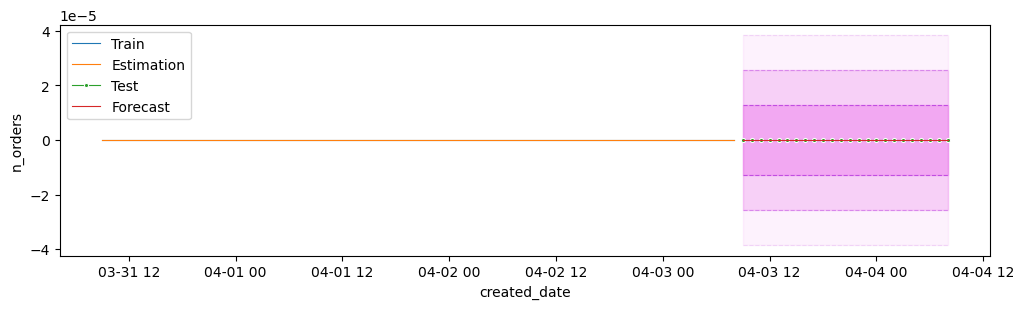

account_id: f9129295-bb08-4330-b60c-9f0beadda521
sales_channel_id: 25
price_total_agg
train RMSE: 325.208
train MAE:  21.131
test RMSE: 0.000
test MAE:  0.000


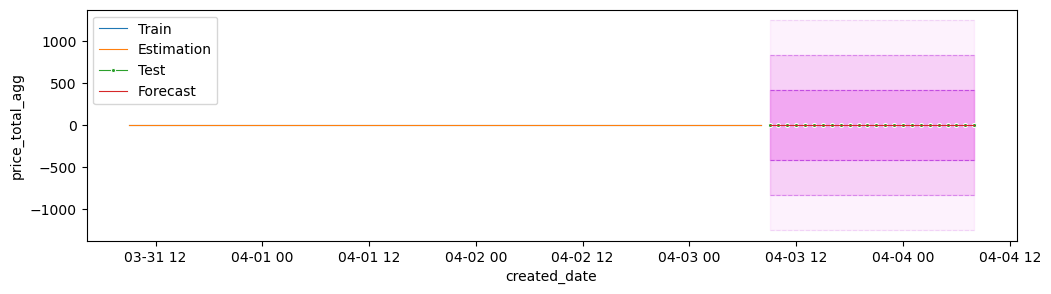

n_orders
train RMSE: 0.178
train MAE:  0.011
test RMSE: 0.000
test MAE:  0.000


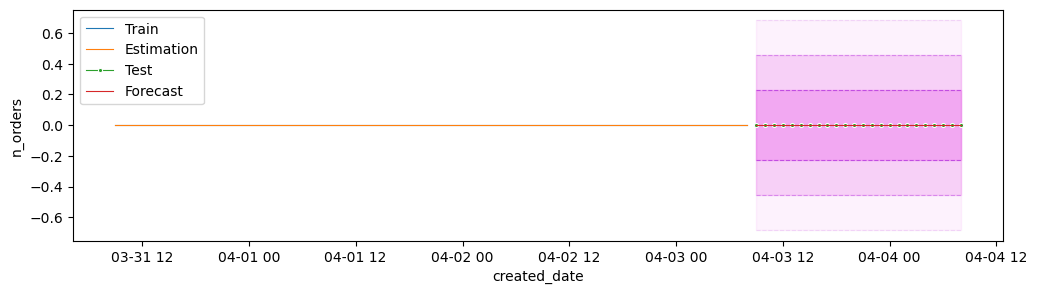

account_id: f9129295-bb08-4330-b60c-9f0beadda521
sales_channel_id: 29
price_total_agg
train RMSE: 292.946
train MAE:  19.604
test RMSE: 0.010
test MAE:  0.003


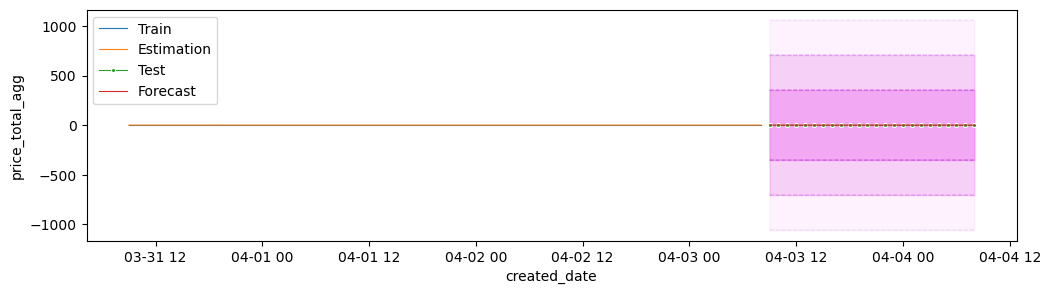

n_orders
train RMSE: 0.066
train MAE:  0.004
test RMSE: 0.000
test MAE:  0.000


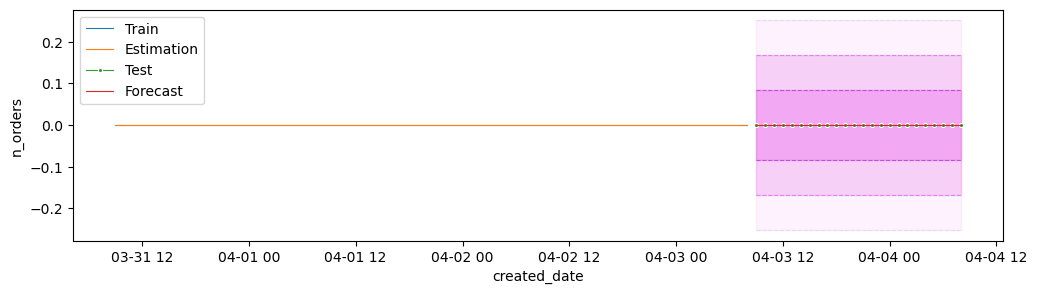

account_id: f9129295-bb08-4330-b60c-9f0beadda521
sales_channel_id: 13
price_total_agg
train RMSE: 0.000
train MAE:  0.000
test RMSE: 0.000
test MAE:  0.000


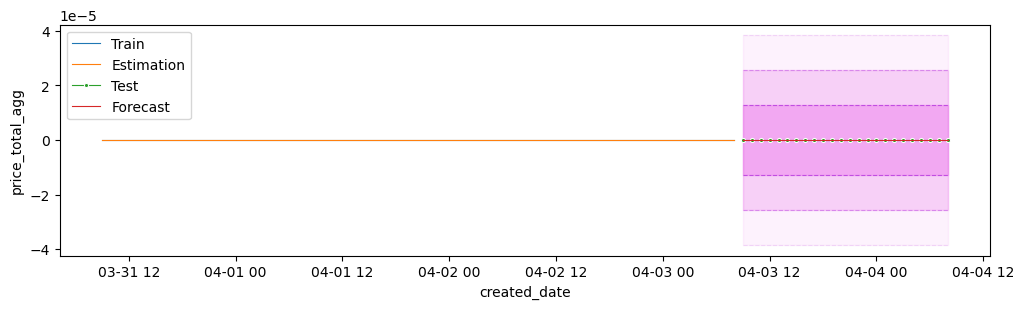

n_orders
train RMSE: 0.000
train MAE:  0.000
test RMSE: 0.000
test MAE:  0.000


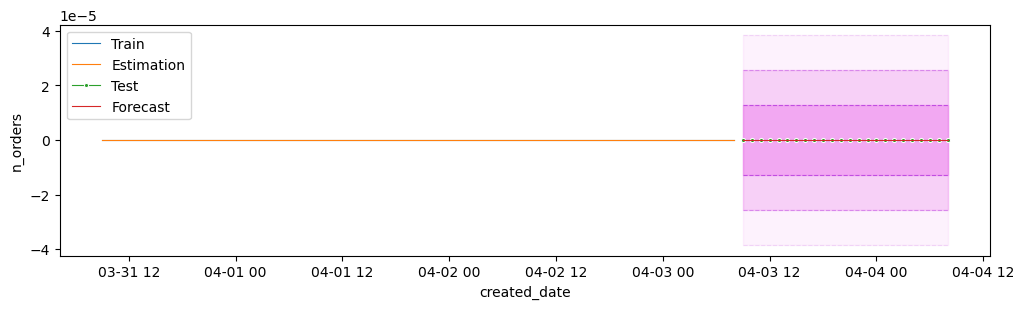

account_id: f9129295-bb08-4330-b60c-9f0beadda521
sales_channel_id: 24
price_total_agg
train RMSE: 0.000
train MAE:  0.000
test RMSE: 0.000
test MAE:  0.000


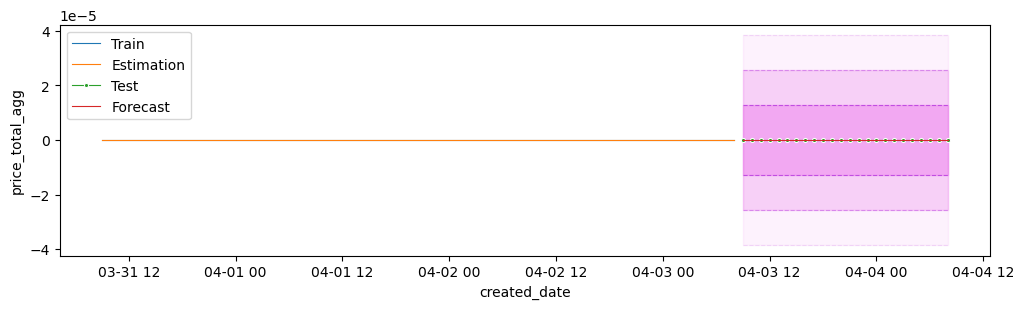

n_orders
train RMSE: 0.000
train MAE:  0.000
test RMSE: 0.000
test MAE:  0.000


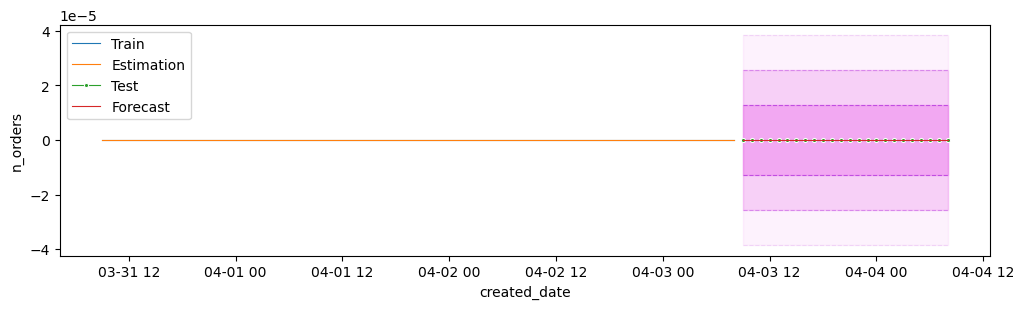

account_id: f9129295-bb08-4330-b60c-9f0beadda521
sales_channel_id: 11
price_total_agg
train RMSE: 1159.351
train MAE:  254.526
test RMSE: 3869.051
test MAE:  1876.259


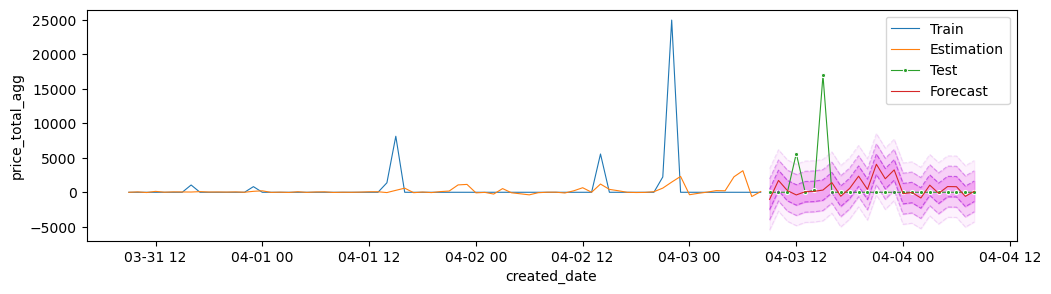

n_orders
train RMSE: 0.366
train MAE:  0.142
test RMSE: 0.704
test MAE:  0.404


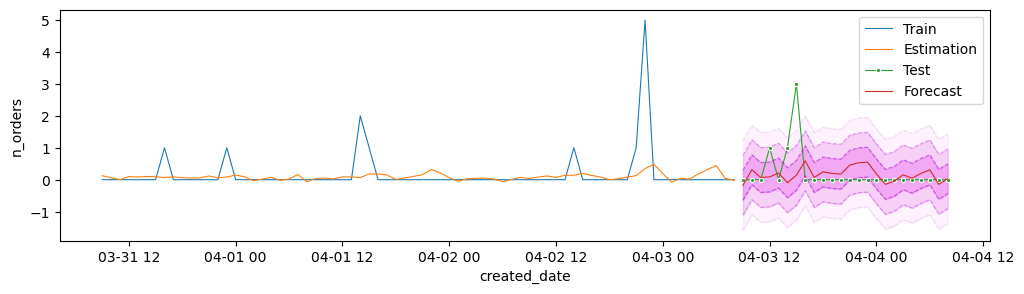

account_id: f9129295-bb08-4330-b60c-9f0beadda521
sales_channel_id: 4
price_total_agg
train RMSE: 918.163
train MAE:  291.697
test RMSE: 163.570
test MAE:  103.529


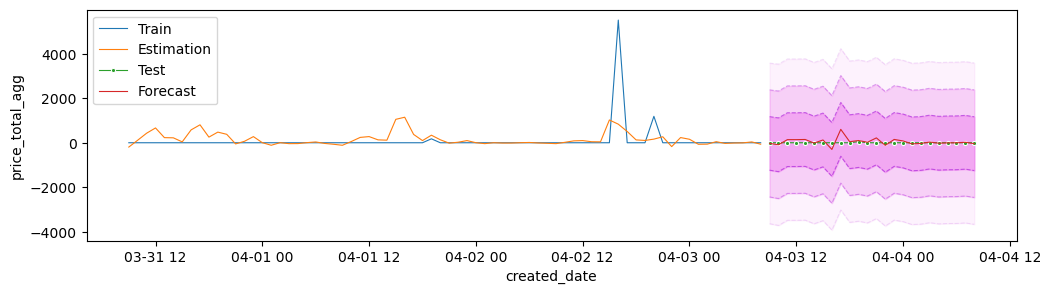

n_orders
train RMSE: 0.304
train MAE:  0.132
test RMSE: 0.203
test MAE:  0.087


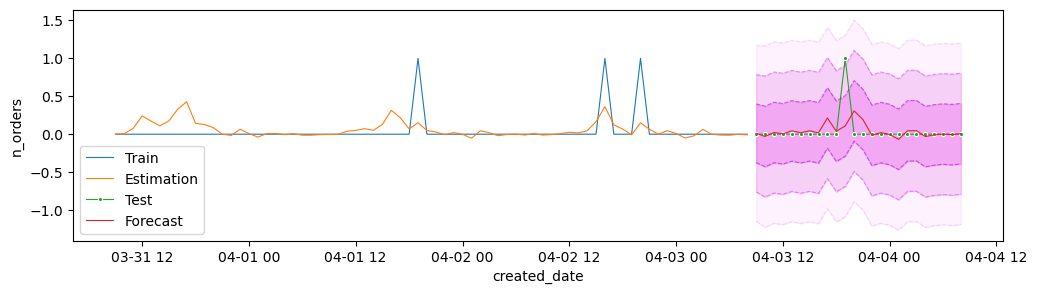

account_id: f9129295-bb08-4330-b60c-9f0beadda521
sales_channel_id: 35
price_total_agg
train RMSE: 1973.191
train MAE:  541.060
test RMSE: 704.399
test MAE:  441.287


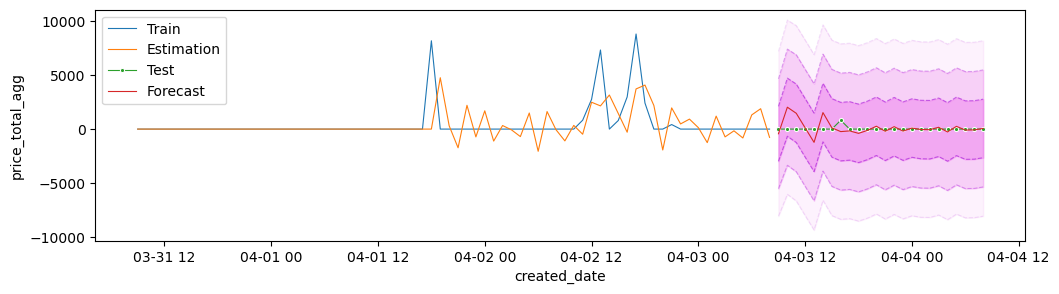

n_orders
train RMSE: 3.710
train MAE:  0.999
test RMSE: 0.809
test MAE:  0.527


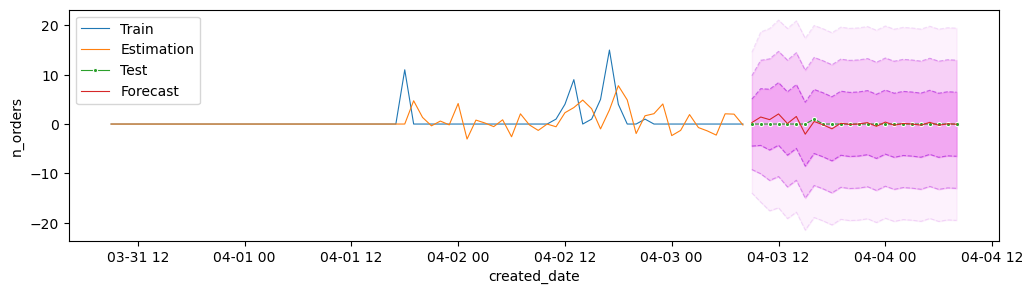

account_id: f9129295-bb08-4330-b60c-9f0beadda521
sales_channel_id: 42
price_total_agg
train RMSE: 0.000
train MAE:  0.000
test RMSE: 0.000
test MAE:  0.000


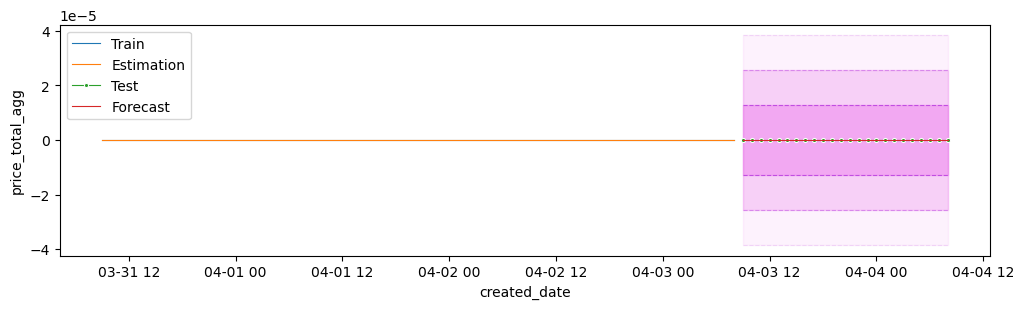

n_orders
train RMSE: 0.000
train MAE:  0.000
test RMSE: 0.000
test MAE:  0.000


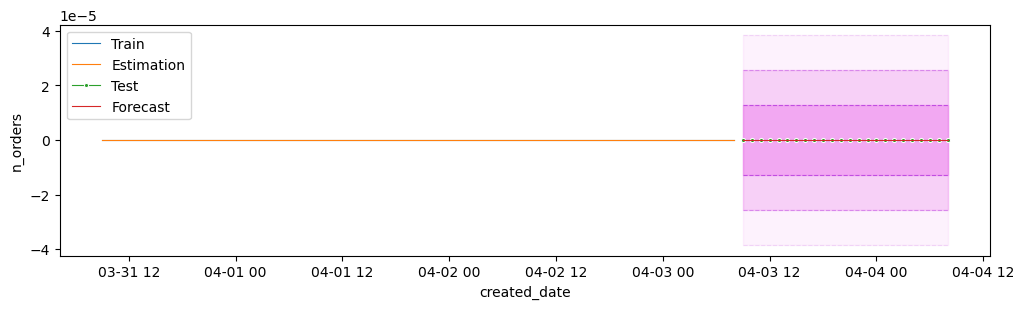

account_id: f9129295-bb08-4330-b60c-9f0beadda521
sales_channel_id: 3
price_total_agg
train RMSE: 1705.193
train MAE:  474.240
test RMSE: 1252.665
test MAE:  631.427


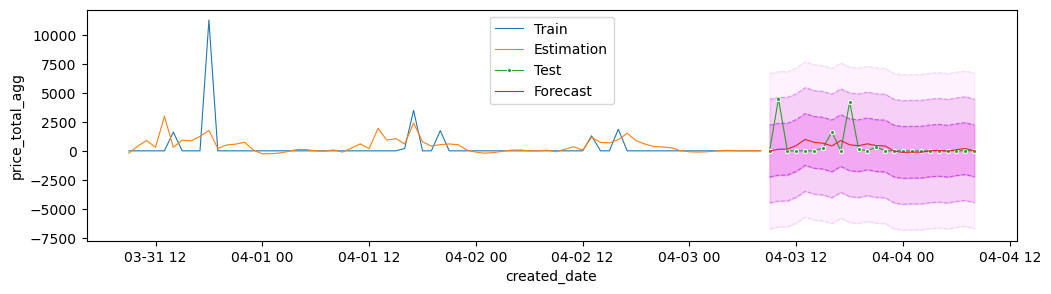

n_orders
train RMSE: 0.458
train MAE:  0.265
test RMSE: 0.398
test MAE:  0.264


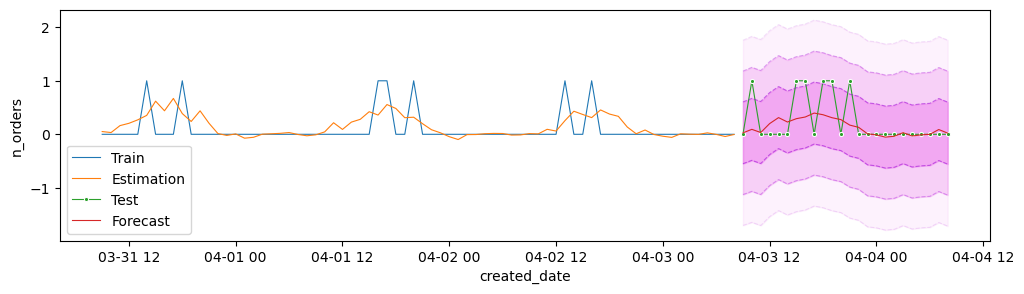

account_id: f9129295-bb08-4330-b60c-9f0beadda521
sales_channel_id: 34
price_total_agg
train RMSE: 278.149
train MAE:  85.831
test RMSE: 990.499
test MAE:  292.710


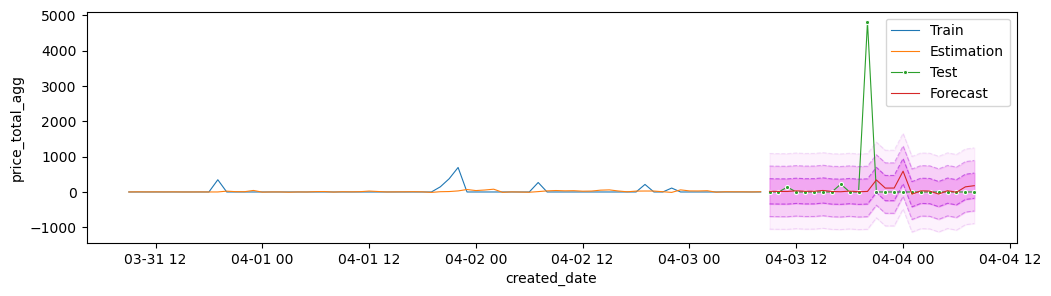

n_orders
train RMSE: 0.394
train MAE:  0.228
test RMSE: 0.507
test MAE:  0.284


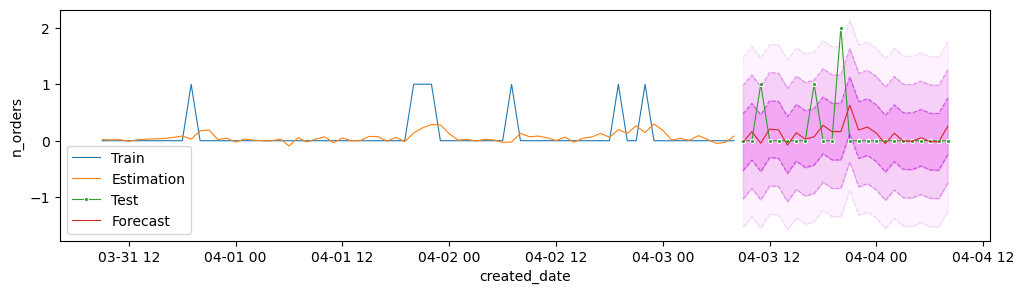

account_id: f9129295-bb08-4330-b60c-9f0beadda521
sales_channel_id: 7
price_total_agg
train RMSE: 1276.366
train MAE:  523.684
test RMSE: 1115.061
test MAE:  477.361


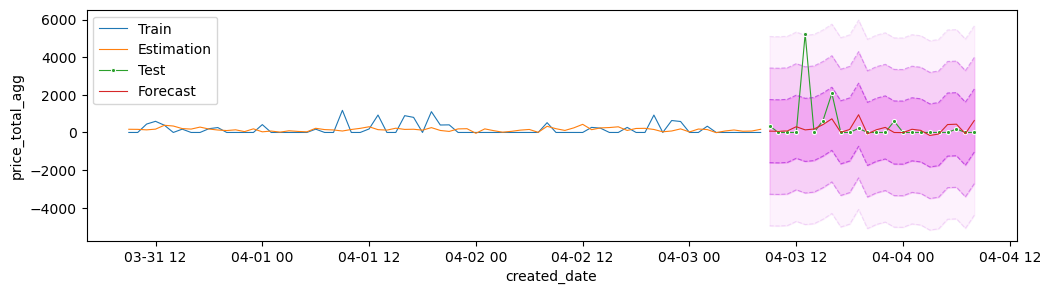

n_orders
train RMSE: 0.738
train MAE:  0.518
test RMSE: 0.574
test MAE:  0.463


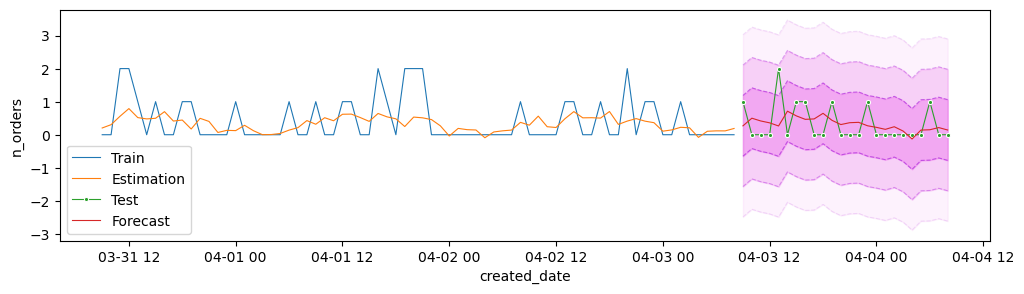

account_id: f9129295-bb08-4330-b60c-9f0beadda521
sales_channel_id: 27
price_total_agg
train RMSE: 3003.905
train MAE:  1666.332
test RMSE: 16240.434
test MAE:  9243.660


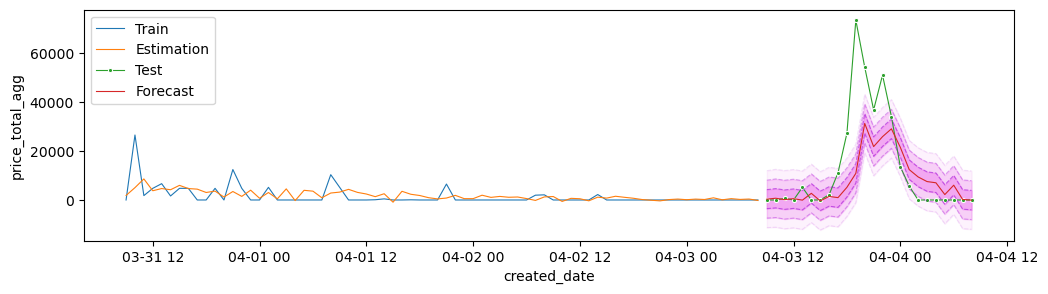

n_orders
train RMSE: 0.769
train MAE:  0.493
test RMSE: 5.392
test MAE:  3.155


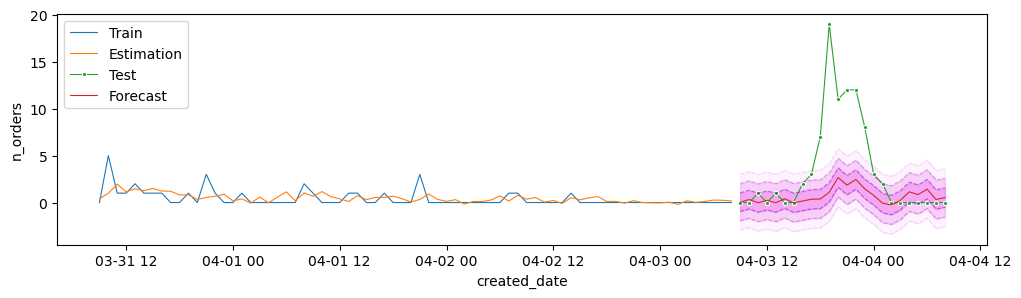

account_id: f9129295-bb08-4330-b60c-9f0beadda521
sales_channel_id: 19
price_total_agg
train RMSE: 2256.691
train MAE:  1424.082
test RMSE: 1632.682
test MAE:  1494.939


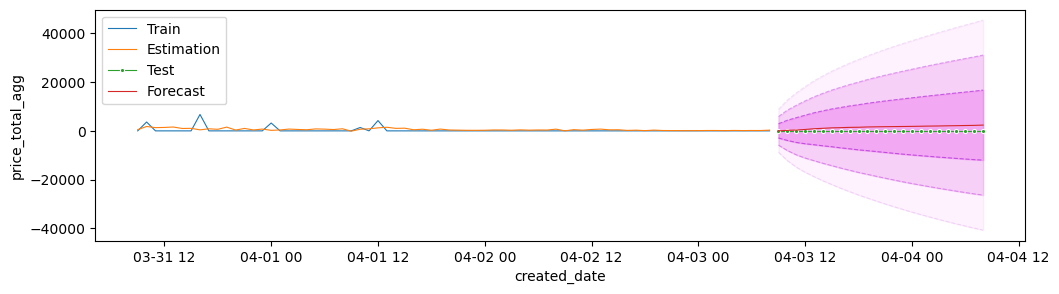

n_orders
train RMSE: 0.695
train MAE:  0.478
test RMSE: 1.330
test MAE:  1.231


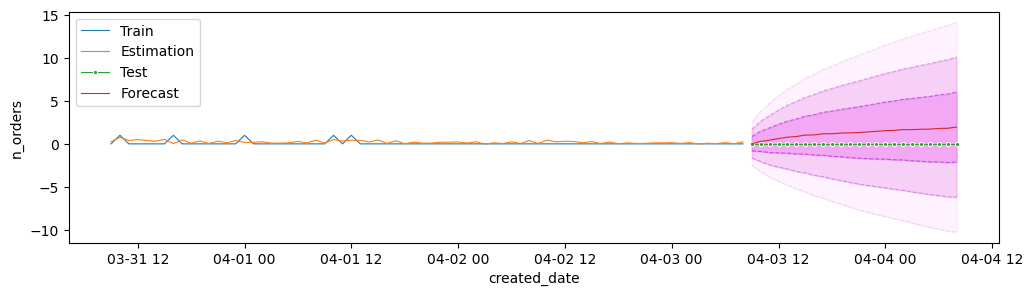

account_id: f9129295-bb08-4330-b60c-9f0beadda521
sales_channel_id: 26
price_total_agg
train RMSE: 2313.263
train MAE:  1208.751
test RMSE: 6876.410
test MAE:  5317.290


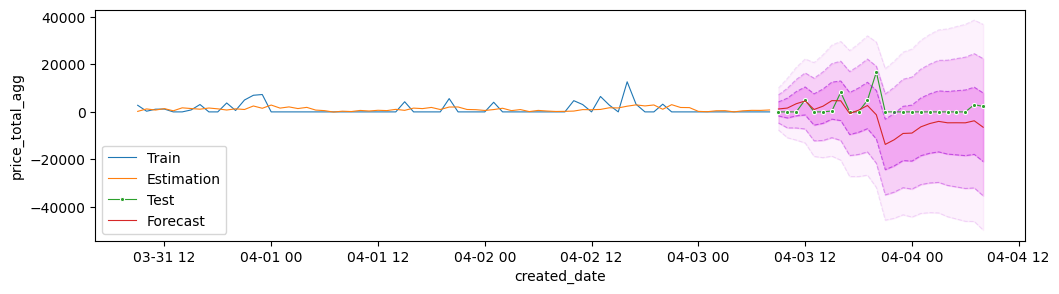

n_orders
train RMSE: 0.608
train MAE:  0.396
test RMSE: 0.669
test MAE:  0.514


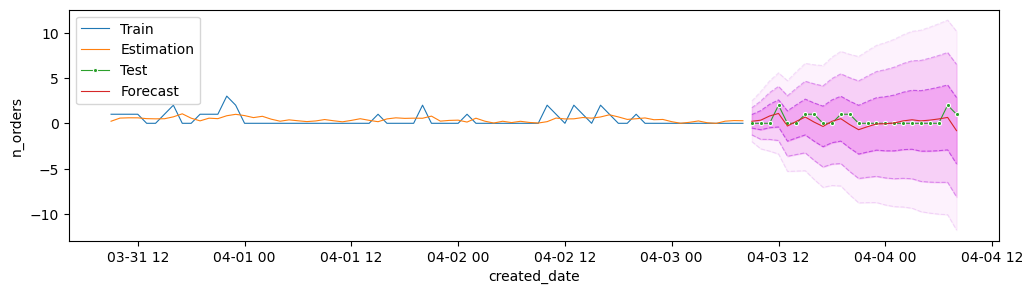

account_id: f9129295-bb08-4330-b60c-9f0beadda521
sales_channel_id: 32
price_total_agg
train RMSE: 1135.137
train MAE:  639.548
test RMSE: 1304.238
test MAE:  836.224


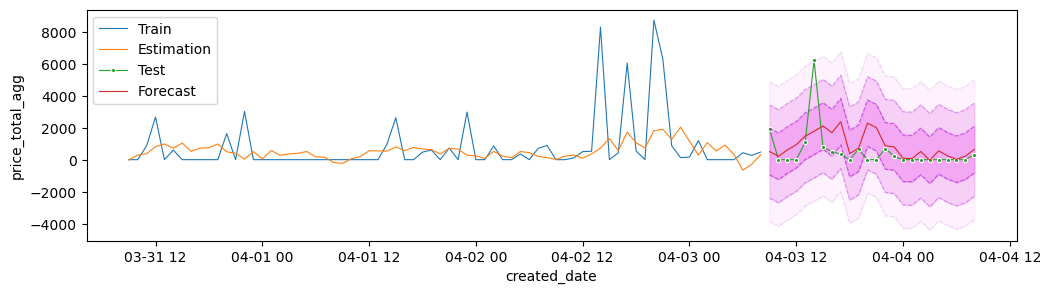

n_orders
train RMSE: 0.862
train MAE:  0.633
test RMSE: 0.710
test MAE:  0.576


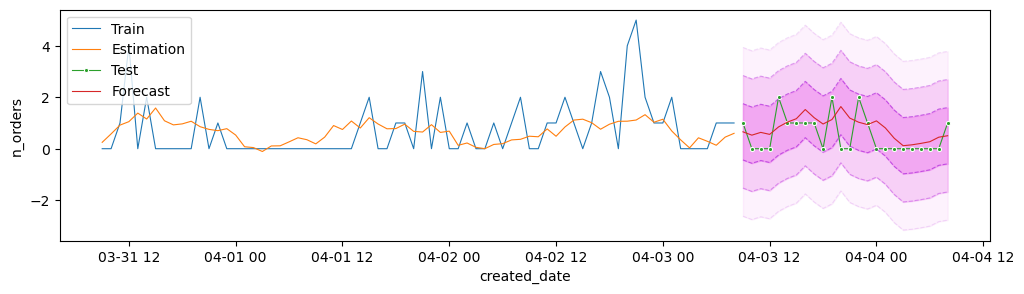

account_id: f9129295-bb08-4330-b60c-9f0beadda521
sales_channel_id: 33
price_total_agg
train RMSE: 2157.280
train MAE:  1105.280
test RMSE: 953.618
test MAE:  616.948


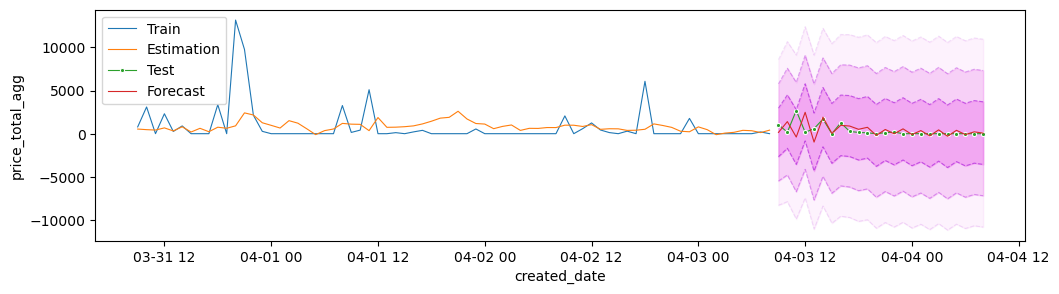

n_orders
train RMSE: 1.162
train MAE:  0.800
test RMSE: 0.626
test MAE:  0.433


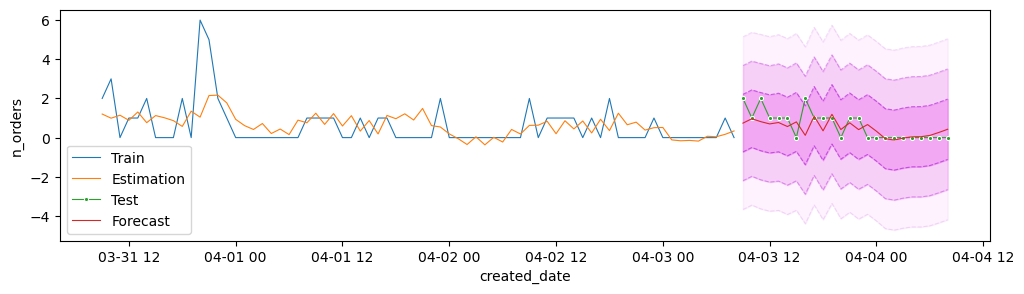

ExclusionViolation: conflicting key value violates exclusion constraint "exclusion_forecast_organization_account_seller_channel_start_en"
DETAIL:  Key (organization_id, account_id, seller, channel, model, minutes_interval, tstzrange(start, "end"))=(f9129295-bb08-4330-b60c-9f0beadda521, f9129295-bb08-4330-b60c-9f0beadda521, ALL, 33, SARIMAX_(2,0,2,1,0,1,24)_80, 60, ["2025-04-03 12:00:00+00","2025-04-03 13:00:00+00")) conflicts with existing key (organization_id, account_id, seller, channel, model, minutes_interval, tstzrange(start, "end"))=(f9129295-bb08-4330-b60c-9f0beadda521, f9129295-bb08-4330-b60c-9f0beadda521, ALL, 33, SARIMAX_(2,0,2,1,0,1,24)_80, 60, ["2025-04-03 12:00:00+00","2025-04-03 13:00:00+00")).


In [ ]:
# id_pairs = list(zip(df_filtered['account_id'], df_filtered['sales_channel_id']))
id_pairs = list(zip(df['account_id'], df['sales_channel_id']))
summary_dict = {}
forecast_dict = {}
# for coverage in [n*10**-1 for n in range(1, 10)]:
for coverage in [0.4]: # DO NOT DELETE!!!
    
    alpha = 1 - coverage
    
    for account_id, sales_channel_id in id_pairs:

        if (account_id, str(sales_channel_id)) in res_forecast:
            continue
        
        print(f'account_id: {account_id}')
        print(f'sales_channel_id: {sales_channel_id}')

        summary_dict[(account_id, sales_channel_id)] = {}
        
        if sales_channel_id == 'ALL':
            cond = (sales['account_id'] == account_id) & \
                   (sales['status'].notna())
        else:
            cond = (sales['account_id'] == account_id) & \
                   (sales['sales_channel_id'] == sales_channel_id) & \
                   (sales['status'].notna())

        df_client = sales[cond].drop(['account_id', 'sales_channel_id'], axis=1)
        df_client['created_date'] = pd.to_datetime(df_client['created_date'], format='%Y-%m-%d %H:%M:%S.%f %z')
        df_client = df_client.sort_values('created_date').reset_index(drop=True)
        df_client['created_date'] = df_client['created_date'].dt.strftime("%Y-%m-%d %H:00:00").reset_index(drop=True)

        df_client_mod = df_client.groupby('created_date').agg(price_total_agg=('price_total', 'sum'), n_orders=('created_date', 'count'))
        df_client_mod.index = pd.to_datetime(df_client_mod.index, format='%Y-%m-%d %H:00:00')

        end_date = pd.to_datetime(END_DATE, format='%Y-%m-%d %H:%M:%S')
        start_date = end_date - relativedelta(months=LOOKBACK)
        date_index = pd.Series(pd.date_range(start=start_date, end=end_date, freq='h', name='created_date'))
        df_client_mod = pd.merge(date_index, df_client_mod, how='left', on='created_date').set_index('created_date')

        # oot_date_index = pd.Series(df_oot.index, name='created_date')
        # combined_date_index = pd.concat([date_index, oot_date_index], axis=0)
        # df_client_mod = pd.merge(combined_date_index, df_client_mod, how='left', on='created_date').set_index('created_date')
        
        df_orders = df_client_mod['n_orders']
            
        df_orders.fillna(0, inplace=True)
        
        orders_lags = [df_orders.shift(l).rename(f'lag_{l}') for l in range(1, 25)]
        df_orders_lag = pd.concat([df_orders, pd.concat(orders_lags, axis=1)], axis=1).dropna().asfreq('h')
        
        # df_orders = df_orders_lag.loc[df_orders_lag.index <= END_DATE].copy()
        df_orders_train = df_orders_lag.loc[df_orders_lag.index < START_DATE].copy()
        df_orders_test = df_orders_lag.loc[(df_orders_lag.index >= START_DATE) & (df_orders_lag.index <= END_DATE)].copy()
        # df_orders_oot = df_orders_lag.loc[df_orders_lag.index > END_DATE].copy()

        # X_orders, y_orders = df_orders.iloc[:, 1:], df_orders.iloc[:, 0]
        X_orders_train, y_orders_train = df_orders_train.iloc[:, 1:], df_orders_train.iloc[:, 0]
        X_orders_test, y_orders_test = df_orders_test.iloc[:, 1:], df_orders_test.iloc[:, 0]
        # X_orders_oot = df_orders_oot.iloc[:, 1:]
        
        orders_model = pm.auto_arima(y_orders_train,
                                     seasonal=True,
                                     m=24,
                                     X=X_orders_train,
                                     freq='h',
                                     d=0,
                                     start_p=0,
                                     start_q=0,
                                     max_p=2,
                                     max_q=2,
                                     D=0,
                                     start_P=0,
                                     start_Q=0,
                                     max_P=2,
                                     max_Q=2)
            
        p, d, q = orders_model.order
        P, D, Q, m = orders_model.seasonal_order

        forecast_dict[account_id] = {} if account_id not in forecast_dict else forecast_dict[account_id]
        forecast_dict[account_id][sales_channel_id] = {}

        for n, col in enumerate(['price_total_agg', 'n_orders']):
            print(col)
            
            summary_dict[(account_id, sales_channel_id)][f'dataset_{n}'] = {}
            summary_dict[(account_id, sales_channel_id)][f'dataset_{n}']['name'] = col
            
            forecast_dict[account_id][sales_channel_id][f'dataset_{n}'] = {}
            
            df = df_client_mod[col]
            
            df.fillna(0, inplace=True)
            
            lags = [df.shift(l).rename(f'lag_{l}') for l in range(1, 25)]
            df_lag = pd.concat([df, pd.concat(lags, axis=1)], axis=1).dropna().asfreq('h')
            
            # df = df_lag.loc[df_lag.index <= END_DATE].copy()
            df_train = df_lag.loc[df_lag.index < START_DATE].copy()
            df_test = df_lag.loc[(df_lag.index >= START_DATE) & (df_lag.index <= END_DATE)].copy()
            # df_oot = df_lag.loc[df_lag.index > END_DATE].copy()

            # X, y = df.iloc[:, 1:], df.iloc[:, 0]
            X_train, y_train = df_train.iloc[:, 1:], df_train.iloc[:, 0]
            X_test, y_test = df_test.iloc[:, 1:], df_test.iloc[:, 0]
            # X_oot = df_oot.iloc[:, 1:]
            
            # mad = np.mean(np.abs(y_train - y_train.mean()))
            
            # model = pm.auto_arima(y_train, seasonal=True, m=24, X=X_train, frequency=24, random_state=42)
            
            # p, d, q = model.order
            # P, D, Q, m = model.seasonal_order
            
            sarimax = SARIMAX(endog=y_train, order=(p, d, q), seasonal_order=(P, D, Q, m), exog=X_train, freq='h')
            model = sarimax.fit()
            
            # estimations = model.predict_in_sample(start=X_train.index[0], end=X_train.index[-1], X=X_train)
            estimations = model.predict(exog=X_train)
            
            train_pred = estimations
            train_mae = mean_absolute_error(y_train, train_pred)
            train_rmse = root_mean_squared_error(y_train, train_pred)

            print(f"train RMSE: {train_rmse:.3f}")
            print(f"train MAE:  {train_mae:.3f}")
            
            # gb_forecast = pd.Series(gb.predict(X_test), index=X_test.index)
            
            # forecast_lower, forecast, forecast_upper = calculate_prediction_intervals(y_test, gb_forecast, confidence_level=coverage, n_bootstrap=300)
            
            # forecast_dict[account_id][sales_channel_id][f'dataset_{n}']['forecast'] = forecast
            # forecast_dict[account_id][sales_channel_id][f'dataset_{n}']['forecast_lower'] = forecast_lower
            # forecast_dict[account_id][sales_channel_id][f'dataset_{n}']['forecast_upper'] = forecast_upper
            
            # forecast_dict[account_id][sales_channel_id][f'dataset_{n}']['oot_forecast'] = []
            # forecast_dict[account_id][sales_channel_id][f'dataset_{n}']['oot_forecast_lower'] = []
            # forecast_dict[account_id][sales_channel_id][f'dataset_{n}']['oot_forecast_upper'] = []
            
            # oot_gscv = GridSearchCV(GradientBoostingRegressor(random_state=42, n_iter_no_change=3),
            #                         param_grid={'max_depth': [1, 2, 4, 8, 16],
            #                                     'subsample': [0.2, 0.4, 0.6, 0.8, 1],
            #                                     'max_features': ['sqrt', 'log2', None]},
            #                         scoring='neg_root_mean_squared_error',
            #                         cv=TimeSeriesSplit(),
            #                         n_jobs=-1,
            #                         verbose=1)
            # oot_gscv.fit(X, y)
            # oot_gb = gscv.best_estimator_
            
            # res_test = model.get_prediction(start=START_DATE, end=END_DATE, exog=X_test).summary_frame(alpha=alpha)
            # forecast_lower = pd.Series(res_test['mean_ci_lower'], X_test.index)
            # forecast = pd.Series(res_test['mean'], X_test.index)
            # forecast_upper = pd.Series(res_test['mean_ci_upper'], X_test.index)
            
            # df_forecast = model.predict(n_periods=TEST_SIZE, X=X_test, return_conf_int=True, alpha=alpha, frequency='h')
            # forecast = df_forecast[0]
            # forecast_lower = pd.Series(df_forecast[1][:, 0], index=X_test.index)
            # forecast_upper = pd.Series(df_forecast[1][:, 1], index=X_test.index)
            
            res_test = model.get_prediction(start=START_DATE, end=END_DATE, exog=X_test).summary_frame(alpha=alpha)
            forecast_lower = pd.Series(res_test['mean_ci_lower'], X_test.index)
            forecast = pd.Series(res_test['mean'], X_test.index)
            forecast_upper = pd.Series(res_test['mean_ci_upper'], X_test.index)
            
            forecast_dict[account_id][sales_channel_id][f'dataset_{n}']['forecast'] = forecast
            forecast_dict[account_id][sales_channel_id][f'dataset_{n}']['forecast_lower'] = forecast_lower
            forecast_dict[account_id][sales_channel_id][f'dataset_{n}']['forecast_upper'] = forecast_upper
            
            test_pred = forecast
            test_mae = mean_absolute_error(y_test, test_pred)
            test_rmse = root_mean_squared_error(y_test, test_pred)

            print(f"test RMSE: {test_rmse:.3f}")
            print(f"test MAE:  {test_mae:.3f}")
            
            summary_dict[(account_id, sales_channel_id)][f'dataset_{n}']['train RMSE'] = train_rmse
            summary_dict[(account_id, sales_channel_id)][f'dataset_{n}']['test RMSE'] = test_rmse
            summary_dict[(account_id, sales_channel_id)][f'dataset_{n}']['train MAE'] = train_mae
            summary_dict[(account_id, sales_channel_id)][f'dataset_{n}']['test MAE'] = test_mae
            
            plt.figure(figsize=(12, 3))
            sns.lineplot(y_train.iloc[-3*TEST_SIZE:], lw=0.8, label='Train')
            sns.lineplot(estimations.iloc[-3*TEST_SIZE:], lw=0.8, label='Estimation')
            sns.lineplot(y_test, lw=0.8, label='Test', marker='o', markersize=3)
            sns.lineplot(forecast, lw=0.8, label='Forecast')
            sns.lineplot(forecast_lower, c='darkviolet', alpha=0.5, linestyle='--', lw=0.8)
            sns.lineplot(forecast_upper, c='darkviolet', alpha=0.5, linestyle='--', lw=0.8)
            sns.lineplot(2*forecast_lower-forecast, c='darkviolet', alpha=0.3, linestyle='--', lw=0.8)
            sns.lineplot(2*forecast_upper-forecast, c='darkviolet', alpha=0.3, linestyle='--', lw=0.8)
            sns.lineplot(3*forecast_lower-2*forecast, c='darkviolet', alpha=0.1, linestyle='--', lw=0.8)
            sns.lineplot(3*forecast_upper-2*forecast, c='darkviolet', alpha=0.1, linestyle='--', lw=0.8)
            # sns.lineplot(oot_forecast, lw=0.8, label='OOT Forecast')
            # sns.lineplot(oot_forecast_lower, c='darkviolet', linestyle='--', lw=0.8)
            # sns.lineplot(oot_forecast_upper, c='darkviolet', linestyle='--', lw=0.8)
            plt.fill_between(x=forecast.index[-TEST_SIZE:],
                             y1=forecast_lower,
                             y2=forecast_upper,
                             color='violet',
                             alpha=0.5)
            plt.fill_between(x=forecast.index[-TEST_SIZE:],
                             y1=2*forecast_lower-forecast,
                             y2=2*forecast_upper-forecast,
                             color='violet',
                             alpha=0.3)
            plt.fill_between(x=forecast.index[-TEST_SIZE:],
                             y1=3*forecast_lower-2*forecast,
                             y2=3*forecast_upper-2*forecast,
                             color='violet',
                             alpha=0.1)
            # plt.fill_between(x=oot_forecast.index,
            #                     y1=oot_forecast_lower,
            #                     y2=oot_forecast_upper,
            #                     color='violet',
            #                     alpha=0.5)
            plt.legend()
            plt.savefig(f'plots/sarimax/forecast_{account_id}_{sales_channel_id}_{col}_sarimax.png')
            plt.show();
            
        

        # with open(f'sql/machine_learning/forecast_{account_id}_{sales_channel_id}_ml.sql', 'w') as output_file:
        #     pt_forecast_lower = forecast_dict[account_id][sales_channel_id]['dataset_0']['forecast_lower']
        #     pt_forecast_upper = forecast_dict[account_id][sales_channel_id]['dataset_0']['forecast_upper']
        #     pt_forecast = forecast_dict[account_id][sales_channel_id]['dataset_0']['forecast']
            
        #     no_forecast_lower = forecast_dict[account_id][sales_channel_id]['dataset_1']['forecast_lower']
        #     no_forecast_upper = forecast_dict[account_id][sales_channel_id]['dataset_1']['forecast_upper']
        #     no_forecast = forecast_dict[account_id][sales_channel_id]['dataset_1']['forecast']
        #     for i in range(len(df_test)):
        #         start_time = df_test.index[i]
        #         end_time = start_time + pd.Timedelta(hours=1)
        #         output_file.write(
        #             f"""
        #             INSERT INTO forecast (id, created, modified, platform, store_name, "start", "end",
        #                                   channel, seller, account_id, organization_id, store_id, minutes_interval,
        #                                   model, orders_high, orders_low, orders_mean, sales_high, sales_low, sales_mean)
        #             VALUES (gen_random_uuid(), now(), now(), 1, (select vtexid from vtex_account where id = '{account_id}'::uuid), '{start_time}', '{end_time}',
        #                     {sales_channel_id}, 'ALL', '{account_id}'::uuid, (select organizationid from vtex_account where id = '{account_id}'::uuid), NULL, 60, 'GradientBoosting',
        #                     {no_forecast_upper.iloc[i]}, {no_forecast_lower.iloc[i]}, {no_forecast.iloc[i]},
        #                     {pt_forecast_upper.iloc[i]}, {pt_forecast_lower.iloc[i]}, {pt_forecast.iloc[i]});
        #             """
        #             )
            
        #     pt_oot_forecast_lower = forecast_dict[account_id][sales_channel_id]['dataset_0']['oot_forecast_lower']
        #     pt_oot_forecast_upper = forecast_dict[account_id][sales_channel_id]['dataset_0']['oot_forecast_upper']
        #     pt_oot_forecast = forecast_dict[account_id][sales_channel_id]['dataset_0']['oot_forecast']
            
        #     no_oot_forecast_lower = forecast_dict[account_id][sales_channel_id]['dataset_1']['oot_forecast_lower']
        #     no_oot_forecast_upper = forecast_dict[account_id][sales_channel_id]['dataset_1']['oot_forecast_upper']
        #     no_oot_forecast = forecast_dict[account_id][sales_channel_id]['dataset_1']['oot_forecast']
        #     for i in range(len(df_oot)):
        #         start_time = df_oot.index[i]
        #         end_time = start_time + pd.Timedelta(hours=1)
        #         output_file.write(
        #             f"""
        #             INSERT INTO forecast (id, created, modified, platform, store_name, "start", "end",
        #                                   channel, seller, account_id, organization_id, store_id, minutes_interval,
        #                                   model, orders_high, orders_low, orders_mean, sales_high, sales_low, sales_mean)
        #             VALUES (gen_random_uuid(), now(), now(), 1, (select vtexid from vtex_account where id = '{account_id}'::uuid), '{start_time}', '{end_time}',
        #                     {sales_channel_id}, 'ALL', '{account_id}'::uuid, (select organizationid from vtex_account where id = '{account_id}'::uuid), NULL, 60, 'GradientBoosting',
        #                     {no_oot_forecast_upper.iloc[i]}, {no_oot_forecast_lower.iloc[i]}, {no_oot_forecast.iloc[i]},
        #                     {pt_oot_forecast_upper.iloc[i]}, {pt_oot_forecast_lower.iloc[i]}, {pt_oot_forecast.iloc[i]});
        #             """     
        #             )
                
        pt_forecast_lower = forecast_dict[account_id][sales_channel_id]['dataset_0']['forecast_lower']
        pt_forecast_upper = forecast_dict[account_id][sales_channel_id]['dataset_0']['forecast_upper']
        pt_forecast = forecast_dict[account_id][sales_channel_id]['dataset_0']['forecast']
        
        no_forecast_lower = forecast_dict[account_id][sales_channel_id]['dataset_1']['forecast_lower']
        no_forecast_upper = forecast_dict[account_id][sales_channel_id]['dataset_1']['forecast_upper']
        no_forecast = forecast_dict[account_id][sales_channel_id]['dataset_1']['forecast']
        for i in range(len(df_test)):
            start_time = df_test.index[i]
            end_time = start_time + pd.Timedelta(hours=1)
            start_time = start_time.tz_localize(SAO_PAULO_TZ)
            end_time = end_time.tz_localize(SAO_PAULO_TZ)
            price_insert = \
                f"""
                INSERT INTO public.forecast (id, created, modified, platform, store_name, "start", "end",
                                             channel, seller, account_id, organization_id, store_id, minutes_interval,
                                             model, orders_high, orders_low, orders_mean, sales_high, sales_low, sales_mean)
                VALUES (gen_random_uuid(), now(), now(), 1, '{account_id}'::uuid, '{start_time}', '{end_time}',
                        '{sales_channel_id}', 'ALL', '{account_id}'::uuid, '{account_id}'::uuid, NULL, 60, 'SARIMAX',
                        {no_forecast_upper.iloc[i]}, {no_forecast_lower.iloc[i]}, {no_forecast.iloc[i]},
                        {pt_forecast_upper.iloc[i]}, {pt_forecast_lower.iloc[i]}, {pt_forecast.iloc[i]});
                """
            cursor.execute(price_insert)
        
        # pt_oot_forecast_lower = forecast_dict[account_id][sales_channel_id]['dataset_0']['oot_forecast_lower']
        # pt_oot_forecast_upper = forecast_dict[account_id][sales_channel_id]['dataset_0']['oot_forecast_upper']
        # pt_oot_forecast = forecast_dict[account_id][sales_channel_id]['dataset_0']['oot_forecast']
        
        # no_oot_forecast_lower = forecast_dict[account_id][sales_channel_id]['dataset_1']['oot_forecast_lower']
        # no_oot_forecast_upper = forecast_dict[account_id][sales_channel_id]['dataset_1']['oot_forecast_upper']
        # no_oot_forecast = forecast_dict[account_id][sales_channel_id]['dataset_1']['oot_forecast']
        # for i in range(len(df_oot)):
        #     start_time = df_oot.index[i]
        #     end_time = start_time + pd.Timedelta(hours=1)
        #     start_time = start_time.tz_localize(SAO_PAULO_TZ)
        #     end_time = end_time.tz_localize(SAO_PAULO_TZ)
        #     oot_insert = \
        #         f"""
        #         INSERT INTO public.forecast (id, created, modified, platform, store_name, "start", "end",
        #                                     channel, seller, account_id, organization_id, store_id, minutes_interval,
        #                                     model, orders_high, orders_low, orders_mean, sales_high, sales_low, sales_mean)
        #         VALUES (gen_random_uuid(), now(), now(), 1, '{account_id}'::uuid, '{start_time}', '{end_time}',
        #                 '{sales_channel_id}', 'ALL', '{account_id}'::uuid, '{account_id}'::uuid, NULL, 60, 'GradientBoosting_{int(100*coverage)}',
        #                 {no_oot_forecast_upper.iloc[i]}, {no_oot_forecast_lower.iloc[i]}, {no_oot_forecast.iloc[i]},
        #                 {pt_oot_forecast_upper.iloc[i]}, {pt_oot_forecast_lower.iloc[i]}, {pt_oot_forecast.iloc[i]});
        #         """
        #     cursor.execute(oot_insert)
            
        cursor.execute('commit;')

In [ ]:
df_client_mod

In [ ]:
forecast

In [ ]:
# cursor.close()